# ALS Exploration Notebook

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import rdata

## Loading in Data

In [2]:
data = pd.read_csv("../data/Application_List_Consolidated.csv", header = 0)
data['Site Area'] = data['Site Area'].str.replace(" ha", "")
data['Site Area'] = pd.to_numeric(data['Site Area'])
data.head()

,Lot Number,Location,User,Site Area,Plot Ratio,Deposit (HK$ M),Estimated Earliest Site Available Date,Period,Rolled over
0,FSSTL 177,"Area 19, Sha Tau Kok Road, Fanling",Commercial / Residential,0.8895,5/9.5,50.0,Apr-1999,1999/2000,0
1,RBL 1143,Adjacent to 16 & 18 South Bay Road,Residential R3,0.1925,0.9,10.0,Oct-1999,1999/2000,0
2,Lot 673 in DD Peng Chau,"Site No 2, Tung Wan, Peng Chau",Residential R3,0.1050,0.6,0.5,Apr-1999,1999/2000,0
3,Lot 1848 in DD Cheung Chau,"Shui Hang, Cheung Chau",Residential R4,1.0700,0.4,2.0,Apr-1999,1999/2000,0
4,Lot 1847 in DD Cheung Chau,"Site 1, Sai Wan, Cheung Chau",Residential R4,0.2130,0.4,1.0,Apr-1999,1999/2000,0


In [3]:
core = pd.read_csv("../data/core.csv", header = 0)
core.head()

/var/folders/yp/wyztsj9s75l9q9cwvlpcq7qw0000gn/T/ipykernel_46743/2028781602.py:1: DtypeWarning: Columns (0: floor, 1: devp_ms3, 2: devp_ms4, 3: mat_date, 4: olp, 5: Intensity, 6: Name, 7: Signal_dir) have mixed types. Specify dtype option on import or set low_memory=False.
  core = pd.read_csv("../data/core.csv", header = 0)


,key,size_f2,size_m2,flrplan,block_unit,block,floor,unit,open,close,...,open_ym1,open_ymc1,open_yw,open_ywc,open_yw1,open_ywc1,cci,ccl,cci_lag1,ccl_lag1
0,009971__11_B,400.0,37.0,009971__B,_B,NaN,11,B,2014-09-19,2014-09-19,...,2014.08,2014.666667,2014.38,2014.716981,2014.37,2014.698113,124.87,127.46,123.67,126.8
1,009971__15_B,400.0,37.0,009971__B,_B,NaN,15,B,2014-09-19,2014-09-19,...,2014.08,2014.666667,2014.38,2014.716981,2014.37,2014.698113,124.87,127.46,123.67,126.8
2,009971__17_A,450.0,42.0,009971__A,_A,NaN,17,A,2014-09-19,2014-09-27,...,2014.08,2014.666667,2014.38,2014.716981,2014.37,2014.698113,124.87,127.46,123.67,126.8
3,009971__17_B,400.0,37.0,009971__B,_B,NaN,17,B,2014-09-19,2014-09-19,...,2014.08,2014.666667,2014.38,2014.716981,2014.37,2014.698113,124.87,127.46,123.67,126.8
4,009971__18_A,450.0,42.0,009971__A,_A,NaN,18,A,2014-09-19,2014-12-20,...,2014.08,2014.666667,2014.38,2014.716981,2014.37,2014.698113,124.87,127.46,123.67,126.8


In [4]:
landsale = pd.read_csv("../data/landsale.csv", header = 0)
landsale.head()

,financial_year,award_date,sale_type,lot_number,location,use,use_category_normalized,site_area_sqm,premium_hkd_m,cancelled,...,gfa_check,min_flat_count,flat_size_restriction,flat_req_special,flat_req_source,flat_req_confidence,consent_development,consent_developer,consent_status,consent_date
0,1985-1986,18/04/1985,auction,STTL 275,SHATIN AREA 14B,IG,industrial,4915.0,12.10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
1,1985-1986,18/04/1985,auction,IL 8571,QUEENSWAY (V.B.PACK NO.1),C/R,commercial_residential_mixed,10690.0,701.28,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pacific Place Phase I,APPROVAL OF DEED OF MUTUAL COVENANT | APPROVAL...,Named development,NaN
2,1985-1986,18/04/1985,auction,STTL 194,SHATIN AREA 41A,R3,residential,11710.0,45.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
3,1985-1986,18/04/1985,auction,STTL 225,SHATIN AREA 41A,R3,residential,9515.0,27.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
4,1985-1986,18/04/1985,auction,STTL 252,SHATIN AREA 41A,R4,residential,960.0,1.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN


## Data Cleaning

### ALS Land

In [5]:
als = data.drop(columns=['Plot Ratio', 'Deposit (HK$ M)']).copy()
als['Estimated Earliest Site Available Date'] = als['Estimated Earliest Site Available Date'].replace("Now", np.nan)
als['Estimated Earliest Site Available Date'] = als.groupby("Lot Number")['Estimated Earliest Site Available Date'].transform("first")
als['Estimated Earliest Site Available Date'] = pd.to_datetime(als['Estimated Earliest Site Available Date'], format= "mixed").dt.strftime("%b-%Y")
als.head()

,Lot Number,Location,User,Site Area,Estimated Earliest Site Available Date,Period,Rolled over
0,FSSTL 177,"Area 19, Sha Tau Kok Road, Fanling",Commercial / Residential,0.8895,Apr-1999,1999/2000,0
1,RBL 1143,Adjacent to 16 & 18 South Bay Road,Residential R3,0.1925,Oct-1999,1999/2000,0
2,Lot 673 in DD Peng Chau,"Site No 2, Tung Wan, Peng Chau",Residential R3,0.1050,Apr-1999,1999/2000,0
3,Lot 1848 in DD Cheung Chau,"Shui Hang, Cheung Chau",Residential R4,1.0700,Apr-1999,1999/2000,0
4,Lot 1847 in DD Cheung Chau,"Site 1, Sai Wan, Cheung Chau",Residential R4,0.2130,Apr-1999,1999/2000,0


In [6]:
residential = {'Residential R1': 'Residential',
               'Residential R2': 'Residential',
               'Residential R3': 'Residential',
               'Residential R4': 'Residential'}

als['User'] = als['User'].replace(residential)

### Land Sale 

In [7]:
landsale.head()

,financial_year,award_date,sale_type,lot_number,location,use,use_category_normalized,site_area_sqm,premium_hkd_m,cancelled,...,gfa_check,min_flat_count,flat_size_restriction,flat_req_special,flat_req_source,flat_req_confidence,consent_development,consent_developer,consent_status,consent_date
0,1985-1986,18/04/1985,auction,STTL 275,SHATIN AREA 14B,IG,industrial,4915.0,12.10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
1,1985-1986,18/04/1985,auction,IL 8571,QUEENSWAY (V.B.PACK NO.1),C/R,commercial_residential_mixed,10690.0,701.28,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pacific Place Phase I,APPROVAL OF DEED OF MUTUAL COVENANT | APPROVAL...,Named development,NaN
2,1985-1986,18/04/1985,auction,STTL 194,SHATIN AREA 41A,R3,residential,11710.0,45.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
3,1985-1986,18/04/1985,auction,STTL 225,SHATIN AREA 41A,R3,residential,9515.0,27.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
4,1985-1986,18/04/1985,auction,STTL 252,SHATIN AREA 41A,R4,residential,960.0,1.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN


In [8]:
landsale['award_date'] = pd.to_datetime(landsale['award_date'], format="mixed")
ls2 = landsale.copy()
ls2['site_area_ha'] = ls2['site_area_sqm'] / 10000
ls2['use_category_normalized'].unique()


<StringArray>
[                  'industrial', 'commercial_residential_mixed',
                  'residential',                   'commercial',
                 'petrol_or_ev',            'transport_parking',
            'special_use_other',         'institutional_public',
                        'hotel',                      'telecom',
                    'logistics',                  'hotel_mixed',
                  'data_centre']
Length: 13, dtype: str

In [9]:
ls3 = ls2[ls2['use_category_normalized'] == 'residential'].copy()
ls3.shape

(539, 45)

In [10]:
ls3[ls3['successful_tenderer'].isna()][['financial_year','award_date', 'lot_number', 'successful_tenderer']]

,financial_year,award_date,lot_number,successful_tenderer
41,1985-1986,1986-02-26,KIL 10874,NaN
65,1986-1987,1986-09-30,LOT 5317 in 51,NaN
75,1986-1987,1986-03-12,NKIL 6023,NaN
99,1986-1987,1987-03-23,LOT 1197 in 253,NaN
105,1987-1988,1987-06-24,NKIL 6040,NaN
134,1987-1988,1988-01-15,LOT 1198 in 253,NaN
167,1988-1989,1988-11-29,KIL 10971,NaN
168,1988-1989,1988-11-29,NKIL 6081,NaN
173,1988-1989,1988-12-22,KIL 10972,NaN
226,1989-1990,1989-12-28,NKIL 5983,NaN


## Data Manipulation

### ALS Land

In [22]:
als = als[als['User'] == 'Residential'].copy()
als2 = als.groupby('Period').agg({'Site Area': 'sum', 'Rolled over': 'sum'})
als2 = als2.reset_index()
als2

,Period,Site Area,Rolled over
0,1999/2000,20.1533,0
1,2001/2002,17.4014,1
2,2002/2003,22.6400,9
3,2005/2006,20.3051,7
4,2006/2007,27.4567,20
5,2007/2008,27.1457,22
6,2008/2009,44.4424,19
7,2009/2010,46.0107,38
8,2010/2011,31.6287,33
9,2011/2012,42.8484,29


In [23]:
als2[['Year_from', 'Year_to']] = als2['Period'].str.split("/", expand=True)
als2['Year_from'] = pd.to_datetime(als2['Year_from'], format = "%Y")
als2

,Period,Site Area,Rolled over,Year_from,Year_to
0,1999/2000,20.1533,0,1999-01-01,2000
1,2001/2002,17.4014,1,2001-01-01,2002
2,2002/2003,22.6400,9,2002-01-01,2003
3,2005/2006,20.3051,7,2005-01-01,2006
4,2006/2007,27.4567,20,2006-01-01,2007
5,2007/2008,27.1457,22,2007-01-01,2008
6,2008/2009,44.4424,19,2008-01-01,2009
7,2009/2010,46.0107,38,2009-01-01,2010
8,2010/2011,31.6287,33,2010-01-01,2011
9,2011/2012,42.8484,29,2011-01-01,2012


### Land Sale 

In [24]:
ls3['Year'] = ls3['award_date'].dt.strftime("%Y")
ls3['Year'] = pd.to_datetime(ls3['Year'], format = "%Y")
ls4 = ls3.groupby("Year")[['site_area_ha']].sum().reset_index()
ls4.head()

,Year,site_area_ha
0,1985-01-01,6.8637
1,1986-01-01,18.0904
2,1987-01-01,14.7493
3,1988-01-01,13.3616
4,1989-01-01,17.6475


## Merging ALS Table with Landsale Table

In [14]:
als3 = als.drop_duplicates(subset=['Lot Number'], keep="first").copy()
print(als3['Rolled over'].sum())
ls5 = landsale[landsale['use_category_normalized'] == 'residential'].copy()

merged1 = als3.merge(ls5, how = 'left', left_on="Lot Number", right_on="lot_number")
merged1_unsuccessful = merged1[merged1['award_date'].isna()].copy()
merged1_successful = merged1[merged1['award_date'].notna()].copy()

merged1_successful.head()

11


,Lot Number,Location,User,Site Area,Estimated Earliest Site Available Date,Period,Rolled over,financial_year,award_date,sale_type,...,gfa_check,min_flat_count,flat_size_restriction,flat_req_special,flat_req_source,flat_req_confidence,consent_development,consent_developer,consent_status,consent_date
0,RBL 1143,Adjacent to 16 & 18 South Bay Road,Residential,0.1925,Oct-1999,1999/2000,0,2000-2001,2000-04-25,auction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
9,TMTL 419,"Area 58, Tuen Mun",Residential,1.9400,Apr-1999,1999/2000,0,1999-2000,1999-04-20,auction,...,NaN,NaN,NaN,NaN,NaN,NaN,Aqua Blue,APPROVAL OF DEED OF MUTUAL COVENANT AND MANAGE...,Named development,12-Jul-02
10,TMTL 371,"Area 58, Tuen Mun",Residential,1.6575,Apr-1999,1999/2000,0,1999-2000,1999-04-08,auction,...,NaN,NaN,NaN,NaN,NaN,NaN,The Hillgrove,APPROVAL OF DEED OF MUTUAL COVENANT AND MANAGE...,Named development,22-Nov-01
11,TMTL 449,"Area 58, Tuen Mun",Residential,1.6800,Apr-1999,1999/2000,0,2007-2008,2007-05-29,auction,...,NaN,NaN,NaN,NaN,NaN,NaN,Jade Grove,APPROVAL OF DEED OF MUTUAL COVENANT AND MANAGE...,Named development,NaN
12,TPTL 167,"Cathay Bungalow, Tai Po Kau",Residential,0.2590,Apr-1999,1999/2000,0,1999-2000,1999-06-29,auction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN


In [15]:
merged1_successful['Year'] = merged1_successful['award_date'].dt.strftime("%Y")
merged1_successful['Tenderer'] = np.where(merged1_successful['parent_developer'].notna(), merged1_successful['parent_developer'], merged1_successful['successful_tenderer'])
res1 = merged1_successful.groupby("Year")[['Tenderer']].nunique().reset_index()

In [16]:
ls6 = ls5[~ls5['lot_number'].isin(merged1_successful['lot_number'])].copy()
ls6 = ls6.dropna(subset=['award_date']) ## mark as not a valid input
ls6['Tenderer'] = np.where(ls6['parent_developer'].notna(), ls6['parent_developer'], ls6['successful_tenderer'])
ls6 = ls6.dropna(subset=['Tenderer']) ## remove as not useful
ls6['Year'] = ls6['award_date'].dt.strftime("%Y")
res2 = ls6.groupby('Year')[['Tenderer']].nunique().reset_index()

## Analysis and Visualisation

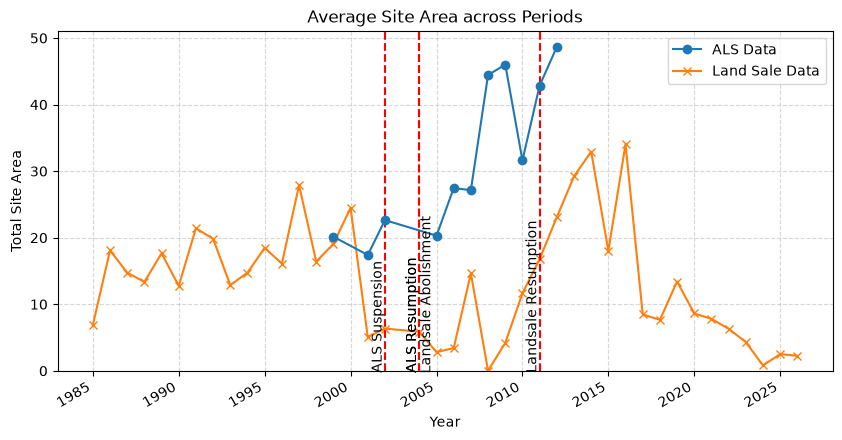

In [26]:
fig, ax = plt.subplots(figsize = (10,5))

als2.plot("Year_from", "Site Area",
         marker = "o",
         xlabel = "Year", ylabel= "Total Site Area",
         title="Average Site Area across Periods", zorder = 3,
         label = "ALS Data",
         ax = ax)

ls4.plot("Year", "site_area_ha", 
         label = "Land Sale Data",
         marker = "x", ax= ax)

ax.axvline(x = "2002-01-01", linestyle = "--", color = "red")
ax.annotate("ALS Suspension", xy= ("2002-01-01", 0.2), ha = 'right', rotation = 90)

ax.axvline(x = "2004-01-01", linestyle = "--", color = "red")
ax.annotate("ALS Resumption", xy= ("2004-01-01", 0.2), ha = 'right', rotation = 90)

ax.axvline(x = "2004-01-01", linestyle = "--", color = "red")
ax.annotate("ALS Resumption", xy= ("2004-01-01", 0.2), ha = 'right', rotation = 90)
ax.annotate("Landsale Abolishment", xy= ("2004-01-01", 0.1), ha = 'left', rotation = 90)

ax.axvline(x = "2011-01-01", linestyle = "--", color = "red")
ax.annotate("Landsale Resumption", xy= ("2011-01-01", 0.2), ha = 'right', rotation = 90)

plt.ylim(bottom=0)
plt.grid(True, linestyle = "--", alpha = 0.5, zorder = 1)
plt.show()

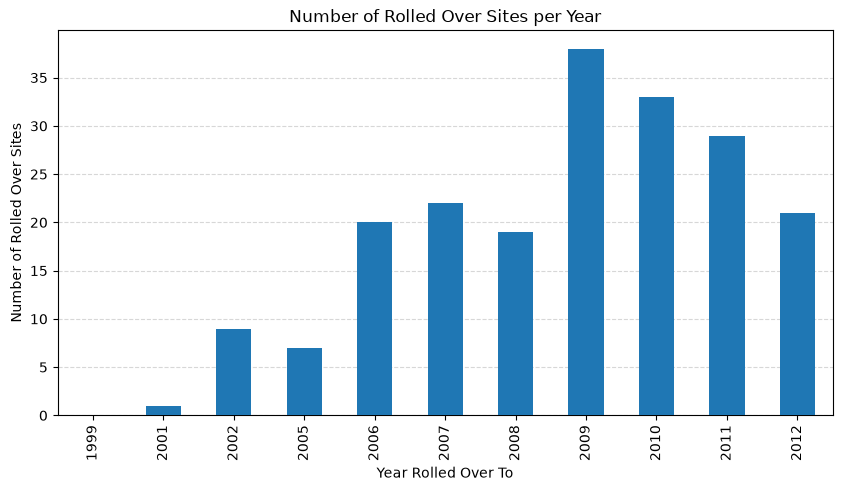

In [18]:
fig, ax = plt.subplots(figsize = (10,5))
als2['Year_from'] = als2['Year_from'].dt.strftime("%Y")
als2.plot(kind = "bar", x= "Year_from", y= "Rolled over", zorder = 3, legend=False, ax = ax)

plt.title("Number of Rolled Over Sites per Year")
plt.xlabel("Year Rolled Over To")
plt.ylabel("Number of Rolled Over Sites")
plt.grid(axis = "y", linestyle = "--", alpha = 0.5, zorder = 1)
plt.show()

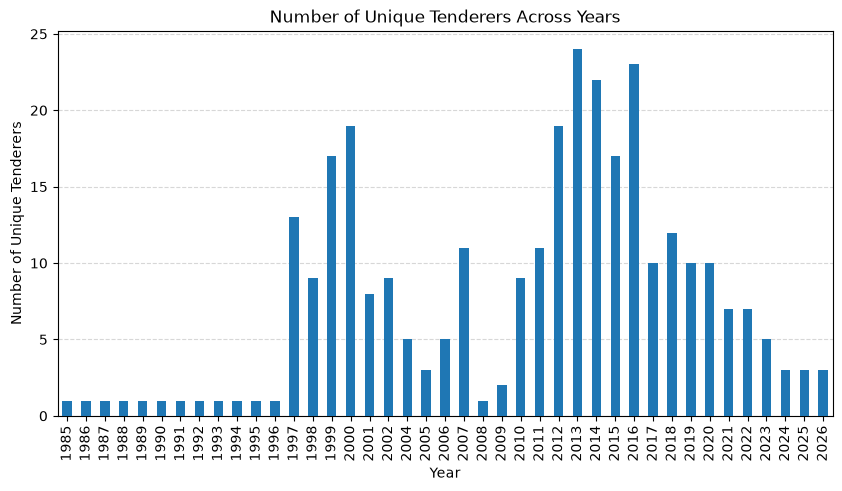

In [19]:
res3 = pd.concat([res1, res2], axis = 0)
res3 = res3.groupby("Year")[['Tenderer']].sum().reset_index()
res3.plot(kind = "bar", x = "Year", y= "Tenderer", 
          xlabel= "Year", ylabel="Number of Unique Tenderers",
          title= "Number of Unique Tenderers Across Years",
          legend=False, figsize = (10,5), zorder = 3 )

plt.grid(axis = "y", linestyle = "--", alpha = 0.5, zorder = 1)
plt.show()

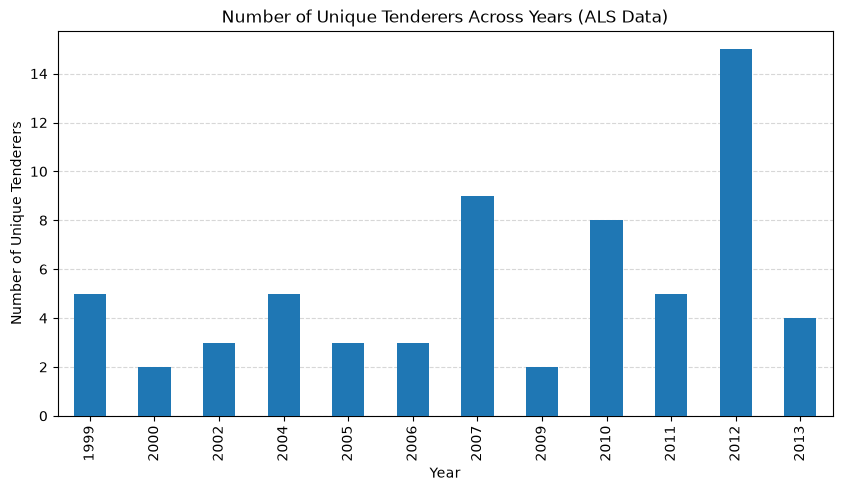

In [21]:
res1.plot(kind = "bar", x = "Year", y= "Tenderer", 
          xlabel= "Year", ylabel="Number of Unique Tenderers",
          title= "Number of Unique Tenderers Across Years (ALS Data)",
          legend=False, figsize = (10,5), zorder = 3 )

plt.grid(axis = "y", linestyle = "--", alpha = 0.5, zorder = 1)
plt.show()